# 1. Time Series Review
# Plot monthly mean discharge and concentration for two hydrological stations

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, probplot, pearsonr, shapiro
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Plotting defaults for publication-quality figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


In [16]:
# Change root to your folder path
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
# root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'

qD   = pd.read_csv(os.path.join(root, 'Q_Diepoldsau_m3s.csv'),       parse_dates=['timestamp']).set_index('timestamp')
qG   = pd.read_csv(os.path.join(root, 'Q_Gisingen_1976-2023.csv'),    parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root, 'SSC_Diepoldsau_gL.csv'),       parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root, 'SSC_Gisingen_2003-2020.csv'),  parse_dates=['timestamp']).set_index('timestamp')


In [17]:
# Quick inspection of raw data
for name, df in [('qD', qD), ('qG', qG), ('sscD', sscD), ('sscG', sscG)]:
    print(f'{name}: {df.shape[0]} rows, range {df.index.min().date()} – {df.index.max().date()}, NaN={df.isna().sum().values[0]}')
display(qD.head(2))
display(qG.head(2))
display(sscD.head(2))
display(sscG.head(2))


qD: 2220121 rows, range 1984-01-01 – 2026-03-18, NaN=0
qG: 1648033 rows, range 1976-01-01 – 2023-01-01, NaN=2
sscD: 711973 rows, range 2012-01-01 – 2026-03-19, NaN=75373
sscG: 596161 rows, range 2004-01-01 – 2021-01-01, NaN=35043


,q_m3s
timestamp,
1984-01-01 00:00:00,113.081
1984-01-01 00:10:00,113.044


,q_m3s
timestamp,
1976-01-01 00:15:00,18.8
1976-01-01 00:30:00,18.7


,ssc_gL
timestamp,
2012-01-01 00:00:00,0.01785
2012-01-01 00:10:00,NaN


,ssc_gL
timestamp,
2004-01-01 00:00:00,0.0153
2004-01-01 00:15:00,0.0143


In [18]:
# Compute monthly means
qD   = qD.resample('ME').mean()
qG   = qG.resample('ME').mean()
sscD = sscD.resample('ME').mean()
sscG = sscG.resample('ME').mean()

# Log-transform to stabilise variance and improve stationarity
for df, name in [(qD, 'qD'), (qG, 'qG'), (sscD, 'sscD'), (sscG, 'sscG')]:
    if (df <= 0).any().any():
        raise ValueError(f'Non-positive values found in {name}; cannot take log.')

qD   = np.log(qD)
qG   = np.log(qG)
sscD = np.log(sscD)
sscG = np.log(sscG)


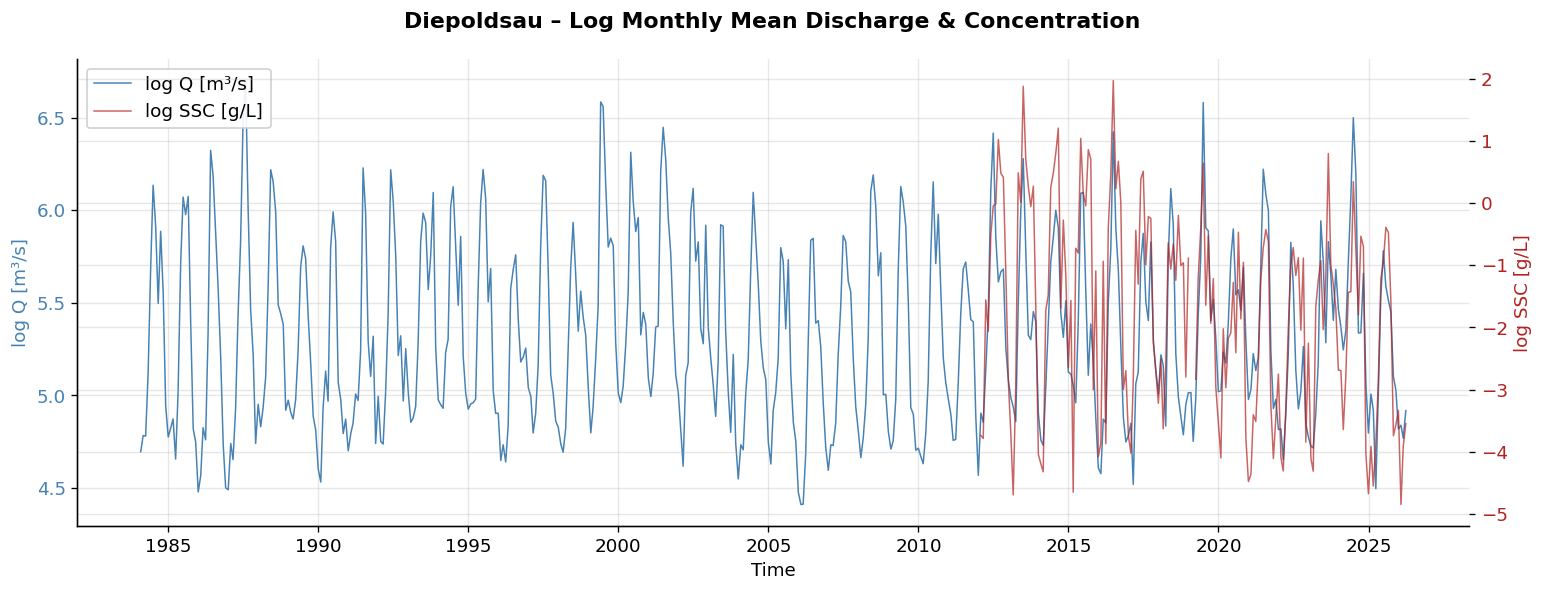

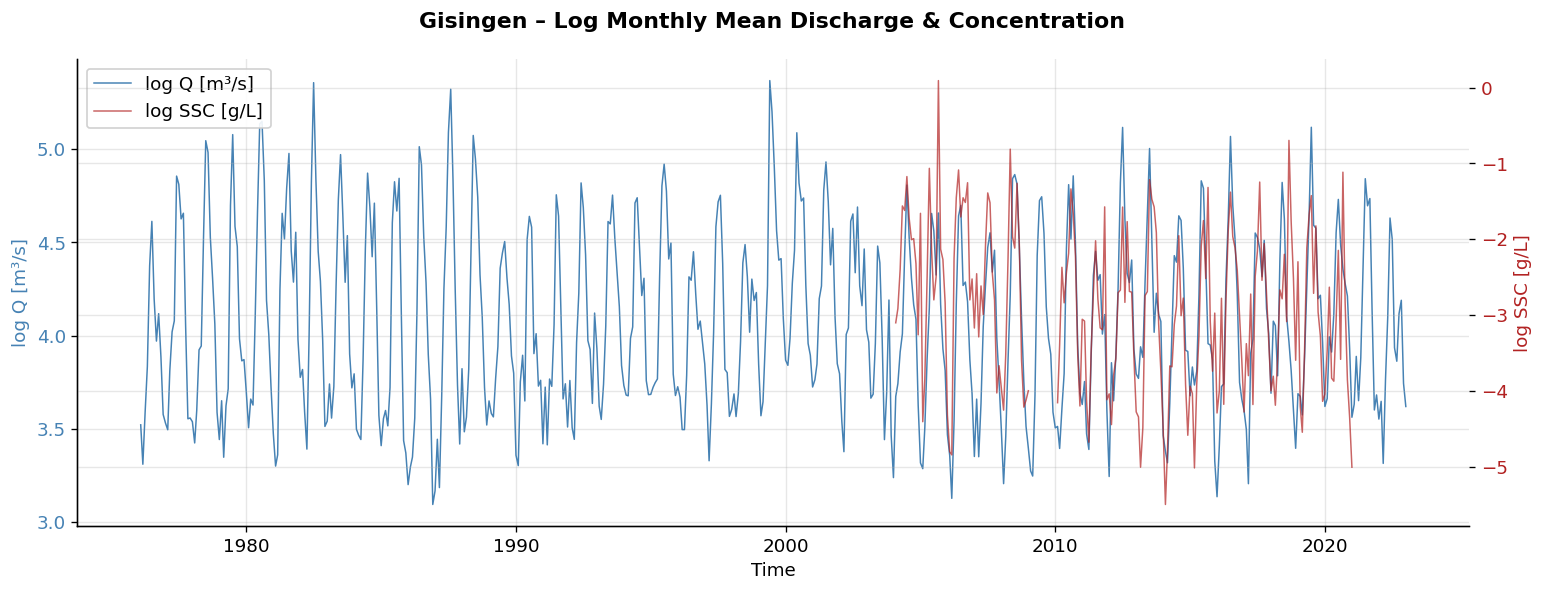

In [19]:
# Plot log-transformed monthly mean Q and C for each station
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(dfQ.index, dfQ['q_m3s'], label='log Q [m³/s]', color='steelblue', linewidth=0.9)
    ax.set_xlabel('Time')
    ax.set_ylabel('log Q [m³/s]', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:, 0], label='log SSC [g/L]', color='firebrick', alpha=0.7, linewidth=0.9)
    ax2.set_ylabel('log SSC [g/L]', color='firebrick')
    ax2.tick_params(axis='y', labelcolor='firebrick')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)
    fig.suptitle(f'{station} – Log Monthly Mean Discharge & Concentration', fontweight='bold')
    fig.tight_layout()
    plt.show()


# 1.2 Stationarity Test and Trend Removal
This section:
1. Fits a linear trend to each log-transformed monthly mean series.
2. Tests slope significance at the 5 % level (t-test from `linregress`).
3. Applies the **Augmented Dickey-Fuller (ADF) test** for unit-root stationarity.
4. Removes any statistically significant linear trend (or subtracts the mean if no trend).
5. Verifies that the detrended series has near-zero mean and finite variance.

In [20]:
def test_and_detrend(df, column_name, alpha=0.05):
    """
    Perform linear trend test and ADF stationarity test.
    Detrend by removing significant linear trend or by mean subtraction.
    Returns (detrended_series, results_dict).
    """
    y = df[column_name].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    significant = trend.pvalue < alpha

    if significant:
        detrended = y.values - (trend.intercept + trend.slope * x)
        detrend_method = 'linear trend removal'
    else:
        detrended = y.values - y.values.mean()
        detrend_method = 'mean subtraction'

    detrended_series = pd.Series(detrended, index=y.index)

    # Augmented Dickey-Fuller test on the ORIGINAL series
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(y.dropna(), autolag='AIC')

    # ADF test on the DETRENDED series
    adf_det_stat, adf_det_p, _, _, adf_det_crit, _ = adfuller(detrended_series.dropna(), autolag='AIC')

    results = {
        'n_points': len(y),
        'slope': trend.slope,
        'r_squared': trend.rvalue ** 2,
        'pvalue_trend': trend.pvalue,
        'trend_significant': significant,
        'detrend_method': detrend_method,
        'mean_after_detrend': detrended.mean(),
        'variance_after_detrend': detrended.var(ddof=1),
        'adf_original_stat': adf_stat,
        'adf_original_p': adf_p,
        'adf_original_crit_5pct': adf_crit['5%'],
        'adf_detrended_stat': adf_det_stat,
        'adf_detrended_p': adf_det_p,
        'adf_detrended_crit_5pct': adf_det_crit['5%'],
    }
    return detrended_series, results


station_results = []
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    for var_label, dfVar, col in [('Q', dfQ, 'q_m3s'), ('C', dfC, dfC.columns[0])]:
        ds, res = test_and_detrend(dfVar, col)
        key = f'{var_label}_{station}'
        detrended_series[key] = ds
        station_results.append({'station': station, 'variable': var_label, **res})

        print(f"--- {station} {var_label} ---")
        print(f"  n={res['n_points']},  slope={res['slope']:.6e},  R²={res['r_squared']:.4f},  p(trend)={res['pvalue_trend']:.4f}")
        print(f"  Trend significant: {res['trend_significant']}  →  method: {res['detrend_method']}")
        print(f"  ADF original:   stat={res['adf_original_stat']:.3f}, p={res['adf_original_p']:.4f}, 5% crit={res['adf_original_crit_5pct']:.3f}")
        print(f"  ADF detrended:  stat={res['adf_detrended_stat']:.3f}, p={res['adf_detrended_p']:.4f}, 5% crit={res['adf_detrended_crit_5pct']:.3f}")
        print(f"  Mean after detrend = {res['mean_after_detrend']:.4e}")
        print(f"  Var  after detrend = {res['variance_after_detrend']:.4e}\n")

station_results_df = pd.DataFrame(station_results)
display(station_results_df)


--- Diepoldsau Q ---
  n=507,  slope=2.476108e-05,  R²=0.0001,  p(trend)=0.8660
  Trend significant: False  →  method: mean subtraction
  ADF original:   stat=-5.143, p=0.0000, 5% crit=-2.867
  ADF detrended:  stat=-5.143, p=0.0000, 5% crit=-2.867
  Mean after detrend = -2.9781e-16
  Var  after detrend = 2.3324e-01

--- Diepoldsau C ---
  n=169,  slope=-9.833803e-03,  R²=0.0855,  p(trend)=0.0001
  Trend significant: True  →  method: linear trend removal
  ADF original:   stat=-0.966, p=0.7653, 5% crit=-2.880
  ADF detrended:  stat=-2.171, p=0.2168, 5% crit=-2.880
  Mean after detrend = -5.2555e-17
  Var  after detrend = 2.4777e+00

--- Gisingen Q ---
  n=564,  slope=4.362672e-07,  R²=0.0000,  p(trend)=0.9972
  Trend significant: False  →  method: mean subtraction
  ADF original:   stat=-4.982, p=0.0000, 5% crit=-2.867
  ADF detrended:  stat=-4.982, p=0.0000, 5% crit=-2.867
  Mean after detrend = -2.0472e-17
  Var  after detrend = 2.3267e-01

--- Gisingen C ---
  n=192,  slope=-3.791594

,station,variable,n_points,slope,r_squared,pvalue_trend,trend_significant,detrend_method,mean_after_detrend,variance_after_detrend,adf_original_stat,adf_original_p,adf_original_crit_5pct,adf_detrended_stat,adf_detrended_p,adf_detrended_crit_5pct
0,Diepoldsau,Q,507,2.476108e-05,5.641893e-05,0.866022,False,mean subtraction,-2.978113e-16,0.233241,-5.143322,0.000011,-2.867432,-5.143322,0.000011,-2.867432
1,Diepoldsau,C,169,-9.833803e-03,8.545653e-02,0.000115,True,linear trend removal,-5.255494e-17,2.477745,-0.966482,0.765292,-2.880252,-2.171460,0.216766,-2.880252
2,Gisingen,Q,564,4.362672e-07,2.172277e-08,0.997213,False,mean subtraction,-2.047220e-17,0.232668,-4.982124,0.000024,-2.866819,-4.982124,0.000024,-2.866819
3,Gisingen,C,192,-3.791594e-03,3.946017e-02,0.005743,True,linear trend removal,7.308968e-16,1.080631,-1.920539,0.322462,-2.877826,-2.136749,0.229997,-2.877826


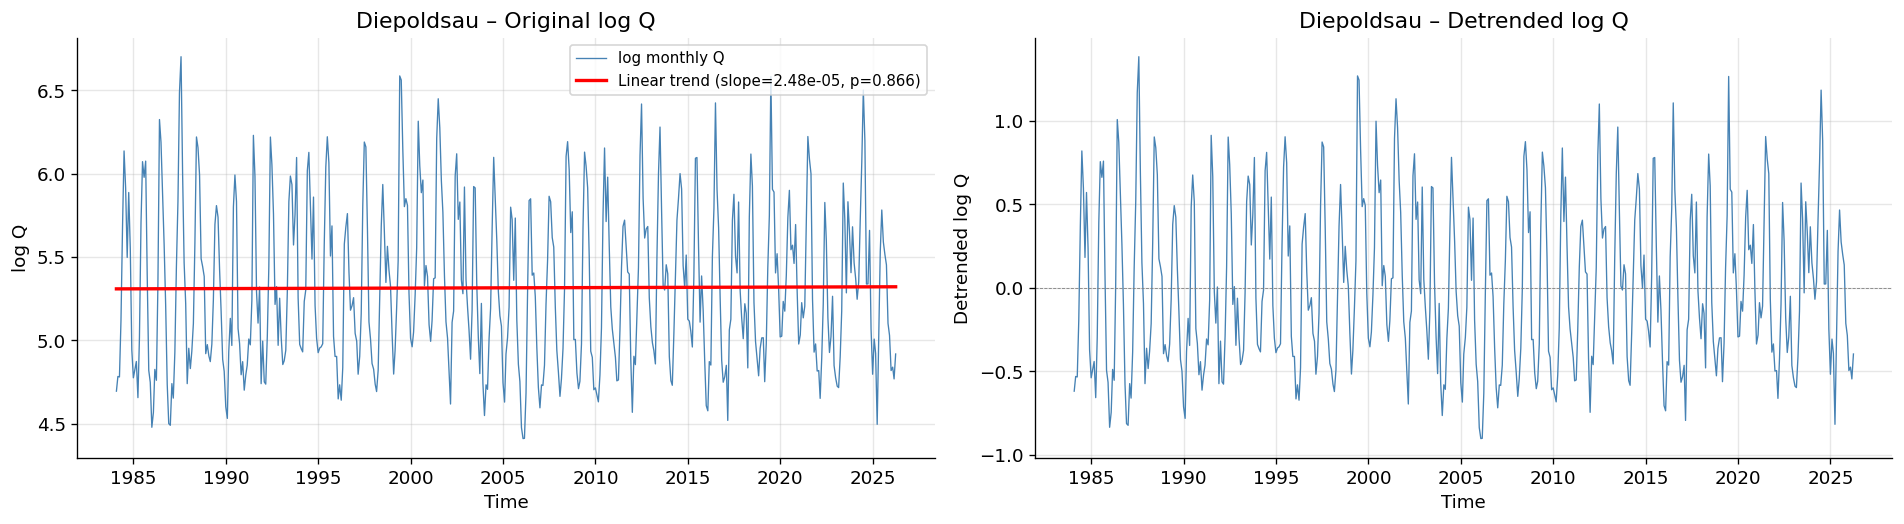

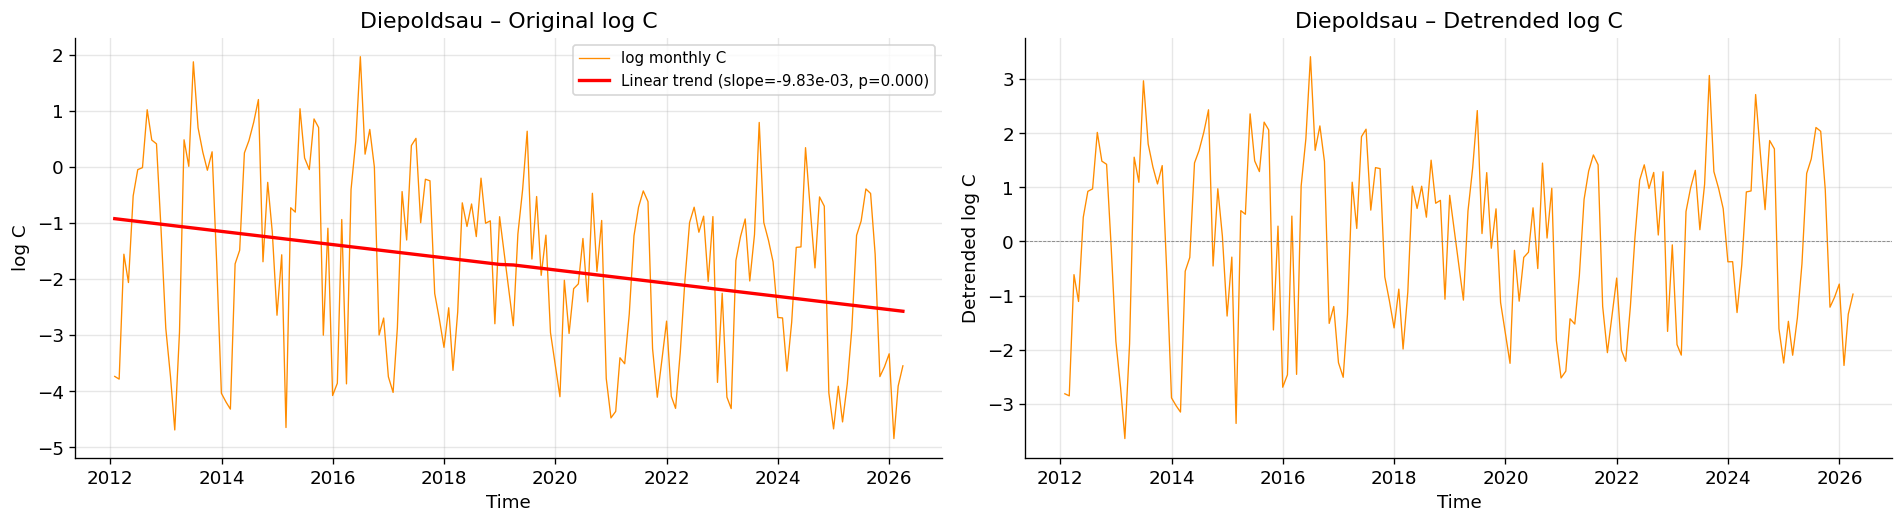

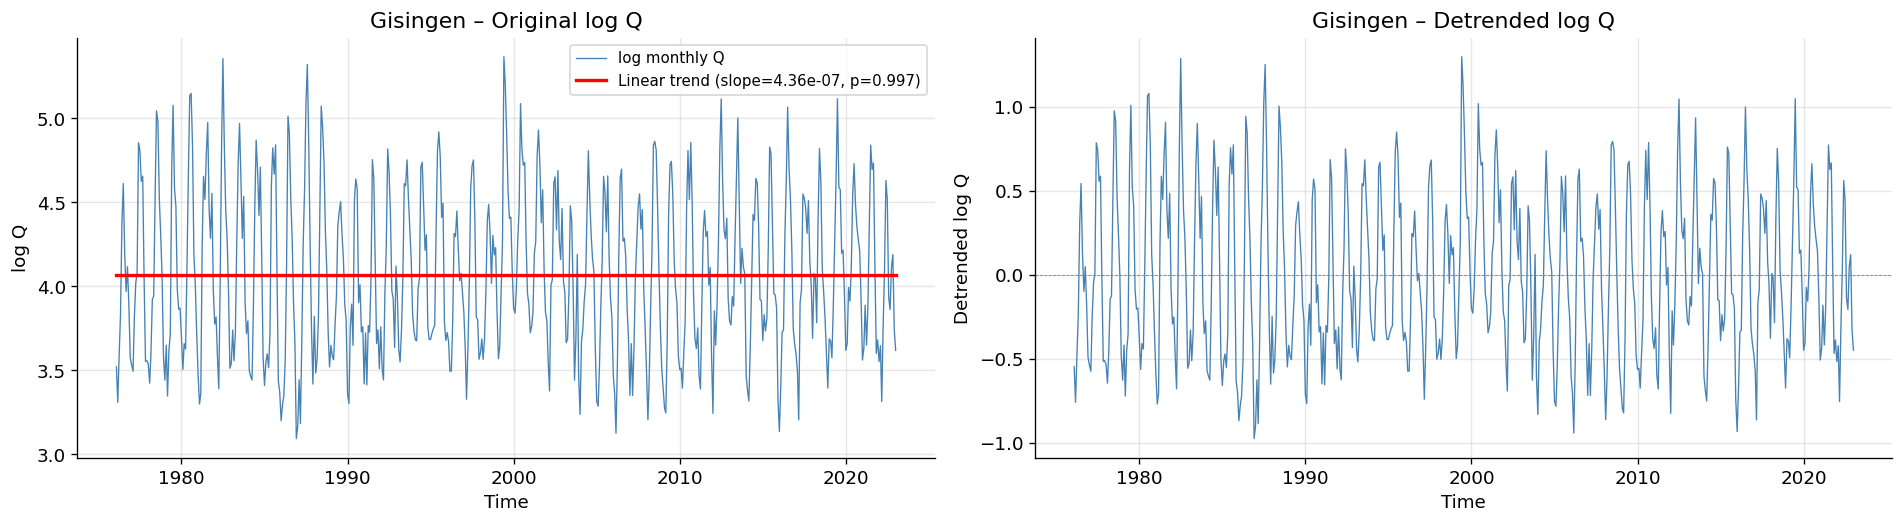

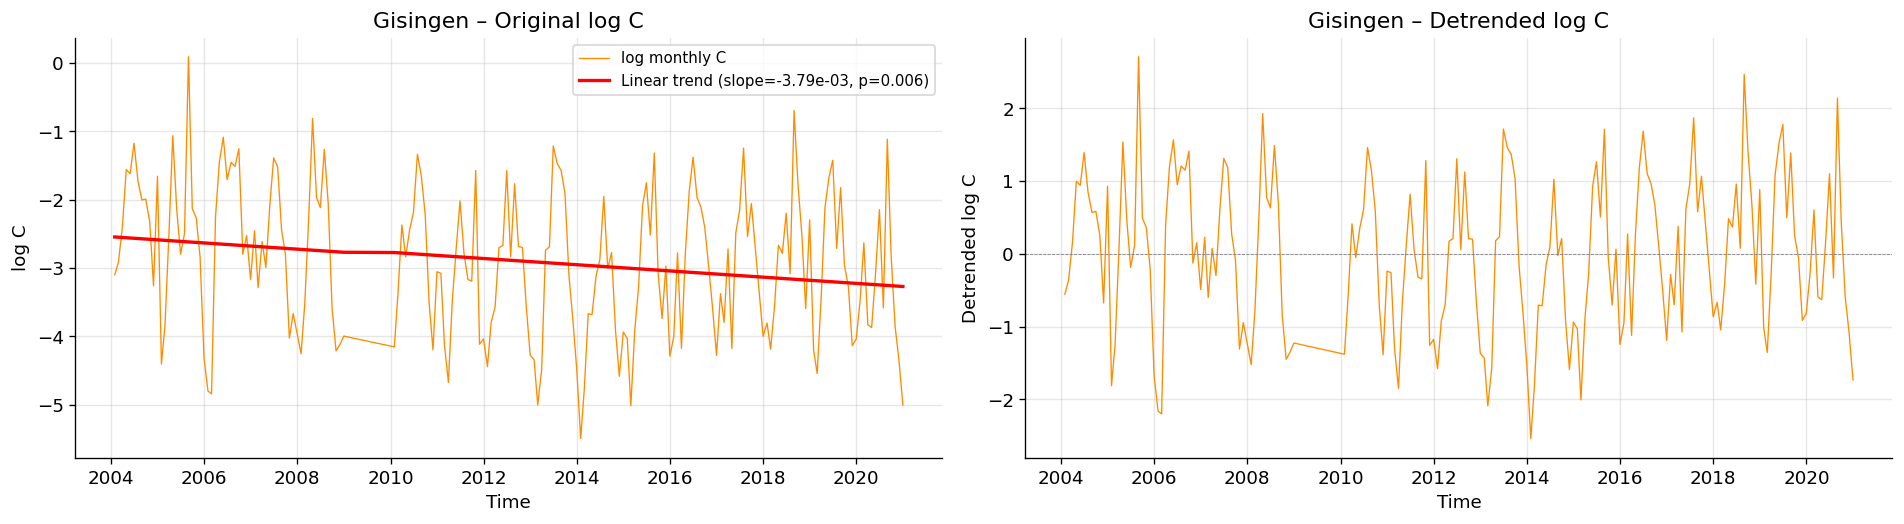

In [21]:
# Plot linear trend fit and original vs detrended comparison
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    for var_label, dfVar, col, color in [('Q', dfQ, 'q_m3s', 'steelblue'),
                                          ('C', dfC, dfC.columns[0], 'darkorange')]:
        y = dfVar[col].dropna()
        x = np.arange(len(y))
        tr = linregress(x, y.values)
        fitted_line = tr.intercept + tr.slope * x
        detrended = detrended_series[f'{var_label}_{station}']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5), sharey=False)

        # Left: original + trend line
        ax1.plot(y.index, y, color=color, linewidth=0.8, label=f'log monthly {var_label}')
        ax1.plot(y.index, fitted_line, 'r-', linewidth=2,
                 label=f'Linear trend (slope={tr.slope:.2e}, p={tr.pvalue:.3f})')
        ax1.set_title(f'{station} – Original log {var_label}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(f'log {var_label}')
        ax1.legend(fontsize=9, loc='best')

        # Right: detrended
        ax2.plot(detrended.index, detrended, color=color, linewidth=0.8)
        ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        ax2.set_title(f'{station} – Detrended log {var_label}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel(f'Detrended log {var_label}')

        fig.tight_layout()
        plt.show()


# 2. Empirical Autocorrelation and Partial Autocorrelation Analysis
Per professor's guidance: SSC data have gaps (Diepoldsau 2019, Gisingen 2009).
We compute ACF/PACF separately before and after each gap, then average them.
We also apply **seasonal standardisation** (Method 1, lecture notes §6.5.3) to remove
the 12-month periodicity before computing ACF/PACF and fitting models.


=== Diepoldsau Q ===
  n after detrend + seasonal standardisation: 507


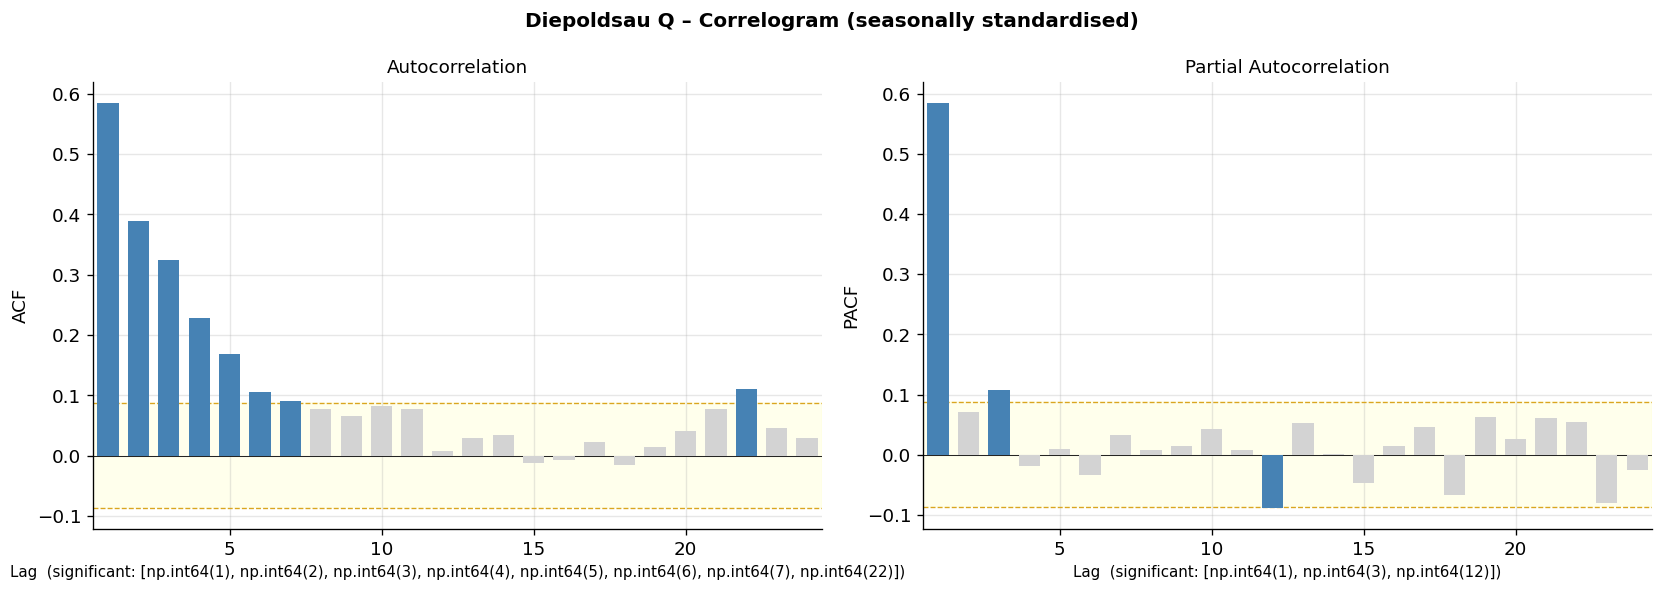


=== Diepoldsau C ===
  n after detrend + seasonal standardisation: 169
  Gap detected at 2019-01-01 – splitting series.
  Segment "before gap": n=84
  Segment "after gap": n=85


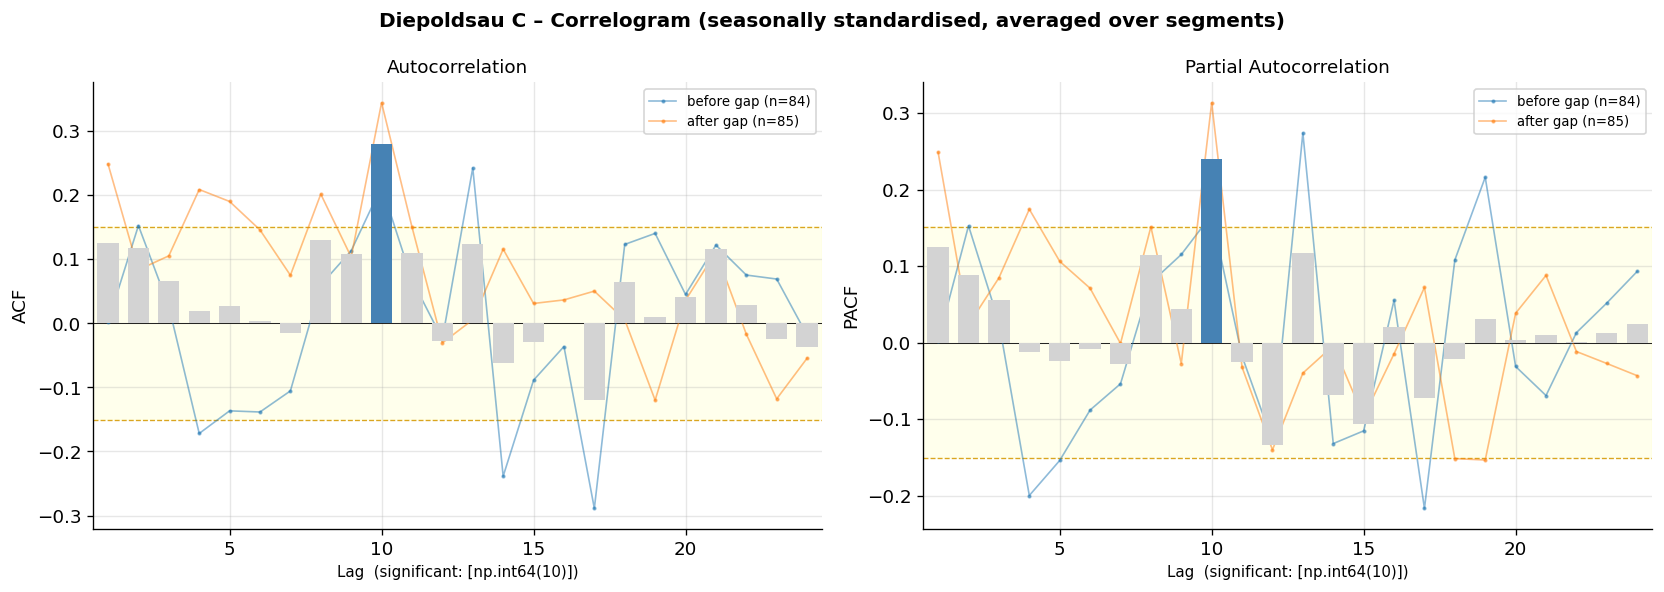

  Pearson r between segment ACFs: -0.101 (p=0.6392)  → different memory structure

=== Gisingen Q ===
  n after detrend + seasonal standardisation: 564


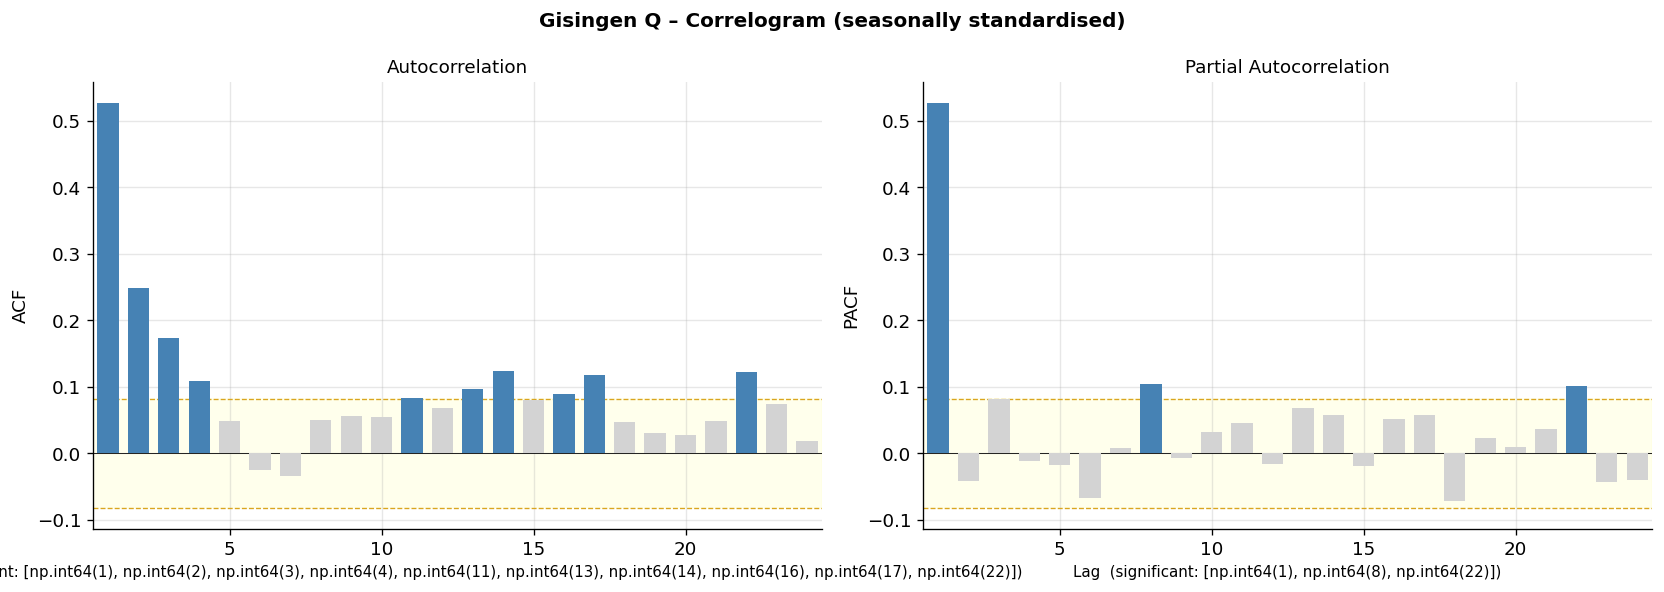


=== Gisingen C ===
  n after detrend + seasonal standardisation: 192
  Gap detected at 2009-01-01 – splitting series.
  Segment "before gap": n=60
  Segment "after gap": n=132


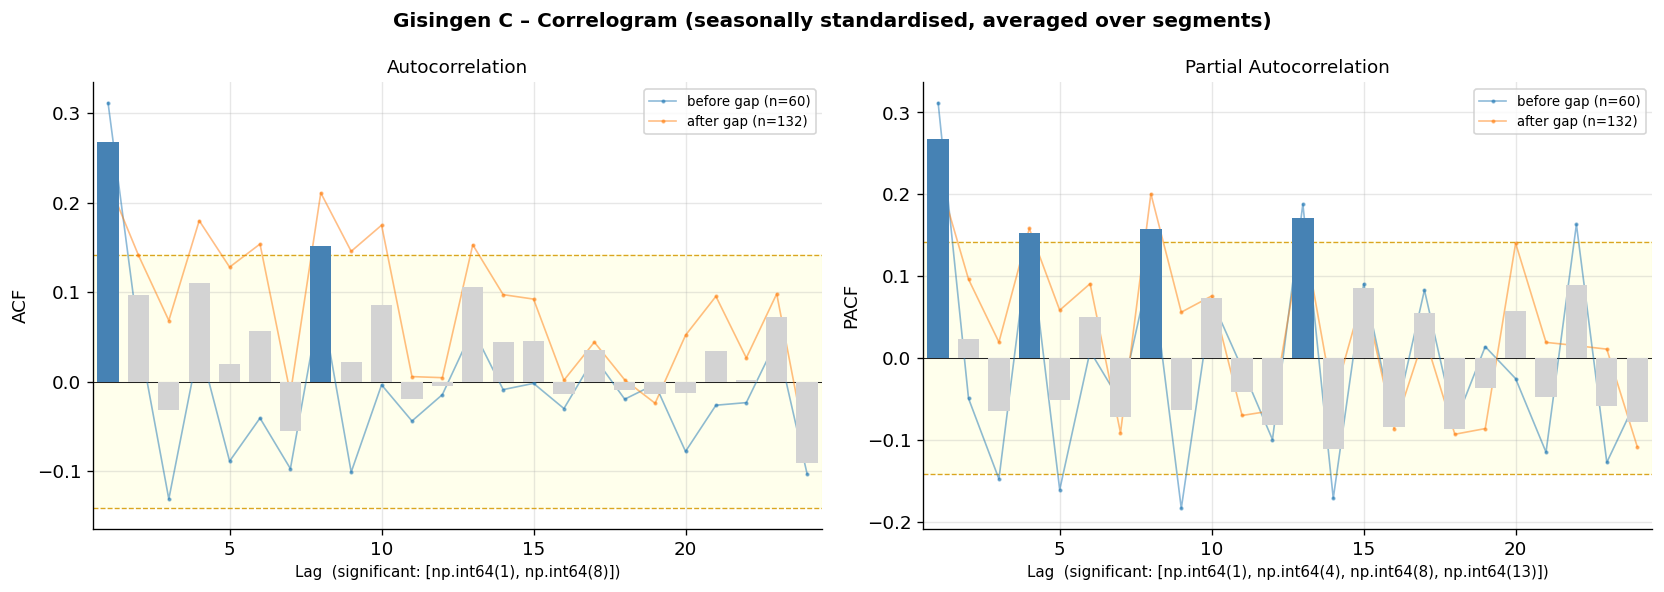

  Pearson r between segment ACFs: 0.557 (p=0.0047)  → different memory structure


In [22]:
# ── Seasonal standardisation ──────────────────────────────────────────────────
# Method 1 (lecture notes §6.5.3): subtract per-month mean, divide by per-month std.
# This removes both the periodic mean and the periodic variance, producing a
# stationary z_t ~ N(0,1) series suitable for AR/ARMA fitting.

def seasonal_standardise(series):
    """Return (standardised series, monthly means, monthly stds)."""
    df = series.to_frame(name='val')
    df['month'] = df.index.month
    monthly_mean = df.groupby('month')['val'].transform('mean')
    monthly_std  = df.groupby('month')['val'].transform('std')
    z = (df['val'] - monthly_mean) / monthly_std
    return z, df.groupby('month')['val'].mean(), df.groupby('month')['val'].std()


# Known data gaps (professor's email):
#   Diepoldsau SSC: 2019  ->  split before 2019 / from 2019
#   Gisingen   SSC: 2009  ->  split before 2009 / from 2009
GAP_CONFIG = {
    'C_Diepoldsau': pd.Timestamp('2019-01-01'),
    'C_Gisingen':   pd.Timestamp('2009-01-01'),
}


def gap_aware_acf_pacf(series, max_lag, gap_date=None):
    """
    Compute ACF/PACF, optionally splitting around a known data gap.
    If gap_date is given: compute on each segment separately and average.
    Returns (acf_avg, pacf_avg, conf, segments_info).
    """
    n_full = len(series.dropna())
    conf = 1.96 / np.sqrt(n_full)

    if gap_date is None:
        s = series.dropna()
        acf_v  = acf(s,  nlags=max_lag, fft=False, missing='drop')
        pacf_v = pacf(s, nlags=max_lag, method='ywm')
        return acf_v, pacf_v, conf, None

    before = series[series.index < gap_date].dropna()
    after  = series[series.index >= gap_date].dropna()
    segments = {}
    acfs, pacfs = [], []
    for label, seg in [('before gap', before), ('after gap', after)]:
        if len(seg) < max_lag + 2:
            print(f'  Segment "{label}" too short ({len(seg)} obs), skipping.')
            continue
        a  = acf(seg,  nlags=max_lag, fft=False, missing='drop')
        p_ = pacf(seg, nlags=max_lag, method='ywm')
        acfs.append(a)
        pacfs.append(p_)
        segments[label] = {'acf': a, 'pacf': p_, 'n': len(seg)}
        print(f'  Segment "{label}": n={len(seg)}')

    if len(acfs) == 0:
        raise ValueError('No valid segments found.')
    acf_avg  = np.mean(acfs,  axis=0)
    pacf_avg = np.mean(pacfs, axis=0)
    return acf_avg, pacf_avg, conf, segments


def plot_correlogram(lags, acf_vals, pacf_vals, conf, title,
                     segment_data=None, figsize=(14, 5)):
    """
    Improved correlogram with:
    - Filled bars coloured by significance (blue = significant, grey = within CI)
    - Shaded 95 % confidence band
    - Lag-0 excluded for clarity
    - Annotated significant lags
    - Optional segment comparison as thin overlaid lines
    """
    plot_lags = lags[1:]  # exclude lag 0
    acf_plot  = acf_vals[1:]
    pacf_plot = pacf_vals[1:]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, vals, ylabel, subtitle in [
        (axes[0], acf_plot,  'ACF',  'Autocorrelation'),
        (axes[1], pacf_plot, 'PACF', 'Partial Autocorrelation'),
    ]:
        # Colour bars by significance
        colors = ['steelblue' if abs(v) > conf else 'lightgrey' for v in vals]
        ax.bar(plot_lags, vals, color=colors, width=0.7, edgecolor='none', zorder=3)

        # Confidence band
        ax.axhspan(-conf, conf, color='lightyellow', alpha=0.6, zorder=1)
        ax.axhline(conf,  color='goldenrod', linewidth=0.8, linestyle='--', zorder=2)
        ax.axhline(-conf, color='goldenrod', linewidth=0.8, linestyle='--', zorder=2)
        ax.axhline(0, color='black', linewidth=0.5, zorder=2)

        # Overlay segment ACFs if available
        if segment_data is not None:
            acf_key = 'acf' if ylabel == 'ACF' else 'pacf'
            for seg_label, seg_info in segment_data.items():
                seg_vals = seg_info[acf_key][1:]
                ax.plot(plot_lags, seg_vals, linewidth=1.0, alpha=0.5,
                        marker='.', markersize=3,
                        label=f'{seg_label} (n={seg_info["n"]})')
            ax.legend(fontsize=8, loc='upper right')

        # Annotate significant lags
        sig_lags = [l for l, v in zip(plot_lags, vals) if abs(v) > conf]
        if sig_lags:
            ax.set_xlabel(f'Lag  (significant: {sig_lags})', fontsize=9)
        else:
            ax.set_xlabel('Lag (all within 95% CI)')
        ax.set_ylabel(ylabel)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlim(0.5, max(plot_lags) + 0.5)

    fig.suptitle(title, fontweight='bold', fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig


max_lag = 24

# Container for the seasonally standardised (z) series used in ARMA fitting
z_series = {}

for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)

    # Step 1: seasonal standardisation
    z, m_mean, m_std = seasonal_standardise(raw_series.dropna())
    z_series[key] = z
    print(f'\n=== {station} {variable} ===')
    print(f'  n after detrend + seasonal standardisation: {len(z)}')

    # Step 2: gap-aware ACF/PACF
    gap_date = GAP_CONFIG.get(key, None)
    if gap_date is not None:
        print(f'  Gap detected at {gap_date.date()} – splitting series.')
    acf_avg, pacf_avg, conf, segments = gap_aware_acf_pacf(z, max_lag, gap_date)

    lags = np.arange(len(acf_avg))

    # Step 3: improved correlogram
    plot_correlogram(
        lags, acf_avg, pacf_avg, conf,
        title=f'{station} {variable} – Correlogram (seasonally standardised'
              + (', averaged over segments)' if segments else ')'),
        segment_data=segments,
    )

    # Segment similarity check
    if segments and len(segments) == 2:
        s1_acf = list(segments.values())[0]['acf'][1:]
        s2_acf = list(segments.values())[1]['acf'][1:]
        r, p = pearsonr(s1_acf, s2_acf)
        print(f'  Pearson r between segment ACFs: {r:.3f} (p={p:.4f})  '
              f'→ {"similar" if r > 0.8 else "different"} memory structure')


# 2.2 AR and ARMA Model Fitting
This section fits AR and ARMA models to the seasonally standardised series for each
station. Model orders are first suggested from the ACF/PACF cutoff, then a grid search
over AR(1..4) and ARMA(1..4, 1..3) is performed. Models are ranked by BIC (parsimony).

In [23]:
# ── Model fitting on the seasonally standardised series ───────────────────────
# Per professor: model order must be <= 12. We scan AR(1..4) and ARMA(1..4, 1..3)
# to keep parsimony. The z_series are already detrended AND deseasonalised.

def select_order_from_acf_pacf(series, max_lag=24, max_order=12):
    """Select ARMA(p,q) order from ACF/PACF cutoff; capped at max_order."""
    n = len(series.dropna())
    conf = 1.96 / np.sqrt(n)
    acf_v  = acf(series.dropna(),  nlags=max_lag, fft=False, missing='drop')
    pacf_v = pacf(series.dropna(), nlags=max_lag, method='ywm')

    # Find first lag where PACF / ACF drops inside the confidence band
    p = 0
    for lag in range(1, max_lag + 1):
        if abs(pacf_v[lag]) > conf:
            p = lag
        else:
            break
    q = 0
    for lag in range(1, max_lag + 1):
        if abs(acf_v[lag]) > conf:
            q = lag
        else:
            break
    return min(p, max_order), min(q, max_order)


def candidate_models(y, max_ar=4, max_ma=3):
    """Fit AR(p) and ARMA(p,q) candidates; return BIC-sorted DataFrame."""
    y = np.asarray(y.dropna(), dtype=float)
    results = []
    for p in range(1, max_ar + 1):
        try:
            m = ARIMA(y, order=(p, 0, 0)).fit()
            results.append(('AR', p, 0, m.aic, m.bic))
        except Exception as e:
            print(f'  AR({p}) failed: {e}')
    for p in range(1, max_ar + 1):
        for q in range(1, max_ma + 1):
            try:
                m = ARIMA(y, order=(p, 0, q)).fit()
                results.append(('ARMA', p, q, m.aic, m.bic))
            except Exception as e:
                print(f'  ARMA({p},{q}) failed: {e}')
    if not results:
        return pd.DataFrame(columns=['model', 'p', 'q', 'aic', 'bic'])
    df = pd.DataFrame(results, columns=['model', 'p', 'q', 'aic', 'bic'])
    df['delta_bic'] = df['bic'] - df['bic'].min()
    return df.sort_values(['bic', 'aic'])


fitted_models = {}

# Toggle: when True, fit ONLY the ACF/PACF-suggested order (p_sug,q_sug).
# If the suggested fit fails, we fall back to the grid search for robustness.
ENFORCE_SUGGESTED_ORDER = True

for key, z in z_series.items():
    variable, station = key.split('_', 1)
    print(f'\n===== {station} {variable} =====')
    if len(z.dropna()) < 10:
        print('  Too few observations – skipping.')
        continue

    p_sug, q_sug = select_order_from_acf_pacf(z)
    print(f'  ACF/PACF suggested: p={p_sug}, q={q_sug}')

    if ENFORCE_SUGGESTED_ORDER:
        # Try fitting the suggested order exclusively
        try:
            fm_sug = ARIMA(z.dropna(), order=(int(p_sug), 0, int(q_sug))).fit()
            fitted_models[f'{key}_SUGGESTED'] = fm_sug
            print(f'  -> Fitted SUGGESTED: ARMA({p_sug},{q_sug})  AIC={fm_sug.aic:.1f}  BIC={fm_sug.bic:.1f}')
            # Skip grid search when suggestion succeeded
            continue
        except Exception as e:
            print(f'  Suggested ARMA({p_sug},{q_sug}) failed: {e}')
            print('  Falling back to candidate grid search...')

    # If not enforcing suggested order, or suggested fit failed, run grid search
    selection = candidate_models(z)
    if selection.empty:
        print('  No model could be fitted.')
        continue
    display(selection.head(12))

    # Best AR (parsimonious – lowest BIC among pure AR models)
    best_ar = selection[selection['q'] == 0].head(1)
    if not best_ar.empty:
        ar_p = int(best_ar['p'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(ar_p, 0, 0)).fit()
            fitted_models[f'{key}_AR'] = fm
            print(f'  -> Best AR: AR({ar_p})  AIC={best_ar.aic.iloc[0]:.1f}  BIC={best_ar.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  AR({ar_p}) refit failed: {e}')

    # Best ARMA (parsimonious – lowest BIC among mixed models)
    best_arma = selection[selection['q'] > 0].head(1)
    if not best_arma.empty:
        arma_p = int(best_arma['p'].iloc[0])
        arma_q = int(best_arma['q'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(arma_p, 0, arma_q)).fit()
            fitted_models[f'{key}_ARMA'] = fm
            print(f'  -> Best ARMA: ARMA({arma_p},{arma_q})  AIC={best_arma.aic.iloc[0]:.1f}  BIC={best_arma.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  ARMA({arma_p},{arma_q}) refit failed: {e}')



===== Diepoldsau Q =====
  ACF/PACF suggested: p=1, q=7
  -> Fitted SUGGESTED: ARMA(1,7)  AIC=1223.9  BIC=1266.2

===== Diepoldsau C =====
  ACF/PACF suggested: p=0, q=0
  -> Fitted SUGGESTED: ARMA(0,0)  AIC=471.2  BIC=477.4

===== Gisingen Q =====
  ACF/PACF suggested: p=1, q=4


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  -> Fitted SUGGESTED: ARMA(1,4)  AIC=1413.2  BIC=1443.6

===== Gisingen C =====
  ACF/PACF suggested: p=1, q=1
  -> Fitted SUGGESTED: ARMA(1,1)  AIC=526.0  BIC=539.0


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# 3. Time Series Model Evaluation
This section evaluates the fitted AR/ARMA models with:
1. **Empirical vs. theoretical ACF** comparison
2. **Residual ACF** and probability plots
3. **Ljung-Box portmanteau test** for residual independence (with d.f. correction)
4. **Shapiro-Wilk** and **PPCC** normality tests on residuals
5. **Durbin-Watson test** for first-order autocorrelation in residuals
6. **Comprehensive summary table** of all diagnostics


===== Diepoldsau Q Evaluation =====


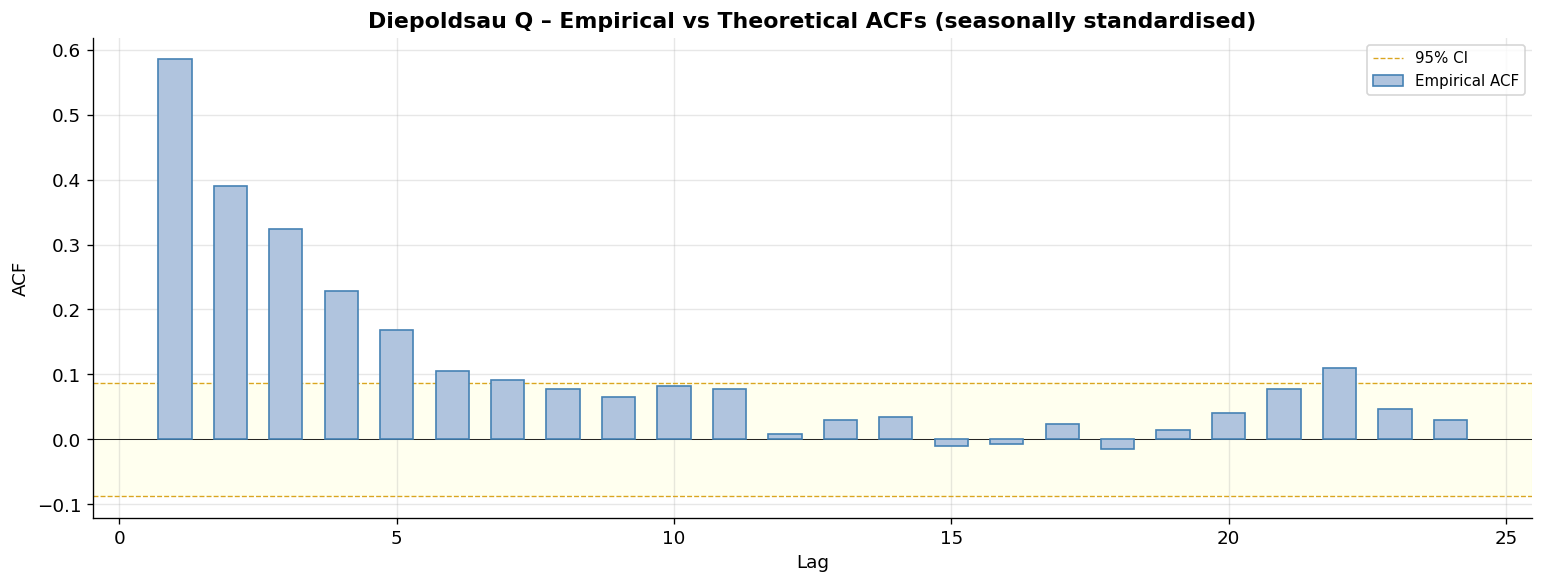


===== Diepoldsau C Evaluation =====


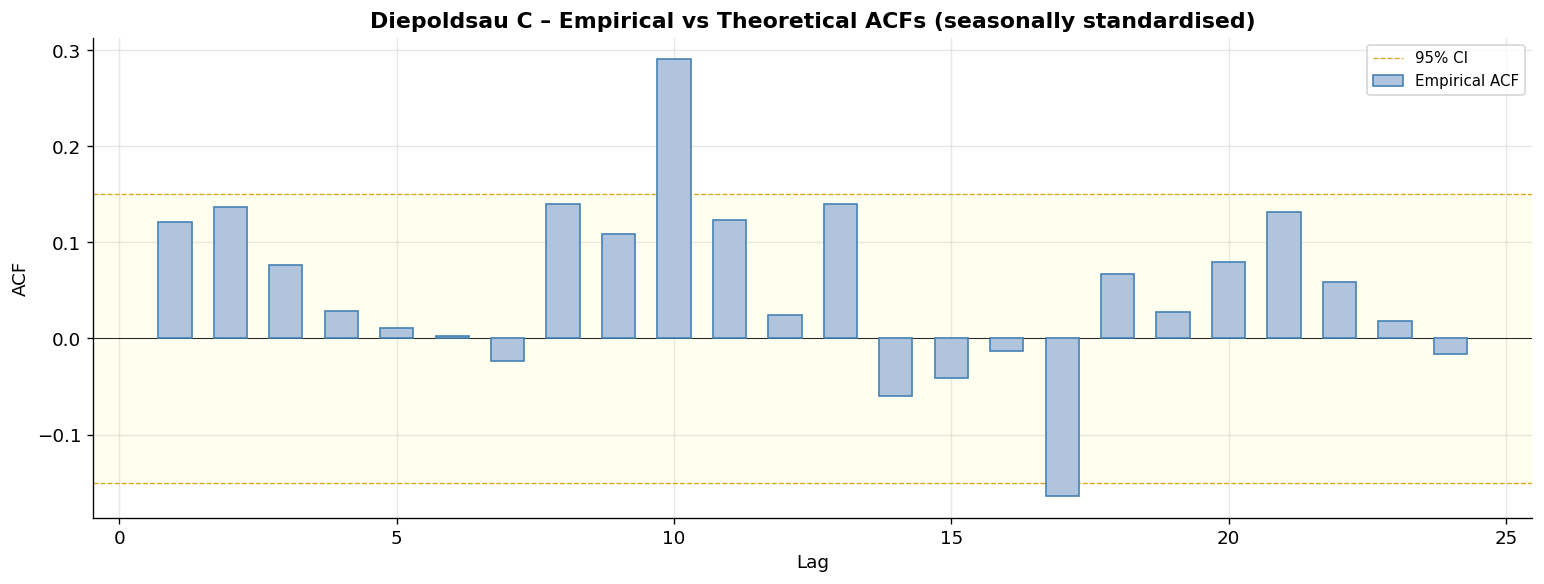


===== Gisingen Q Evaluation =====


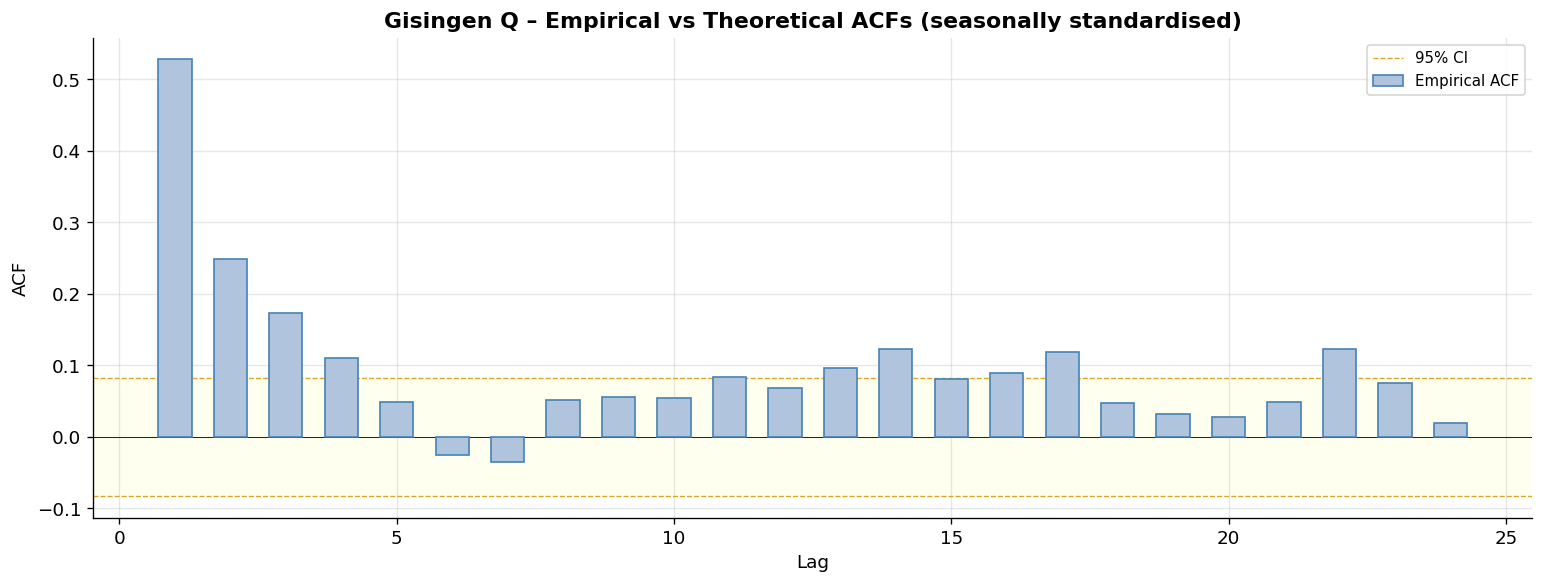


===== Gisingen C Evaluation =====


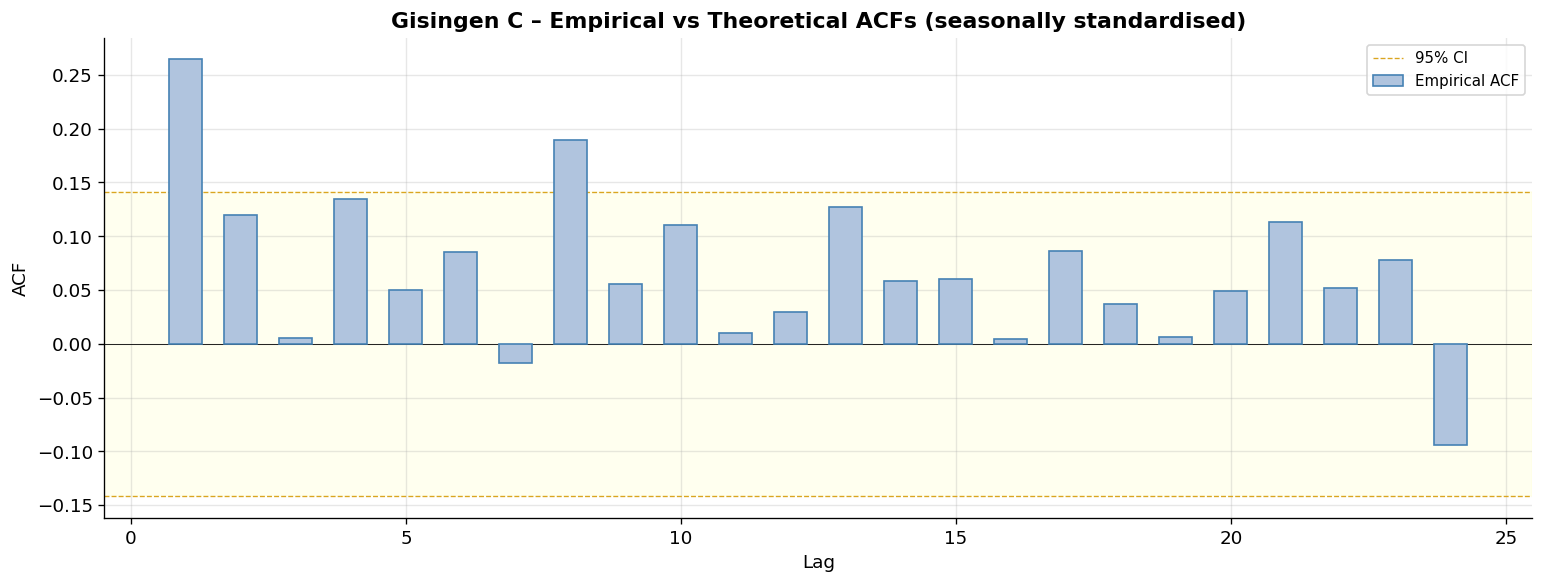

In [24]:
# ── Model evaluation: Empirical vs theoretical ACF + residual diagnostics ─────

max_lag = 24

def theoretical_acf(model_obj, max_lag):
    """Compute theoretical ACF from fitted ARIMA model using ArmaProcess.
    Returns None if the process is non-stationary (roots outside unit circle)."""
    ar = np.r_[1, -model_obj.arparams]  # statsmodels sign convention
    ma = np.r_[1,  model_obj.maparams]
    if len(ar) > 1:
        roots = np.roots(ar)
        if np.any(np.abs(roots) >= 1.0):
            print(f'  Warning: AR polynomial has root >= 1 (max |root|={np.max(np.abs(roots)):.3f})'
                  f' – theoretical ACF cannot be computed.')
            return None
    return ArmaProcess(ar, ma).acf(max_lag + 1)[1:]


for key, z in z_series.items():
    variable, station = key.split('_', 1)
    z_clean = z.dropna()
    n = len(z_clean)
    conf = 1.96 / np.sqrt(n)
    emp_acf = acf(z_clean, nlags=max_lag, fft=False, missing='drop')
    lags = np.arange(1, max_lag + 1)

    ar_model   = fitted_models.get(f'{key}_AR')
    arma_model = fitted_models.get(f'{key}_ARMA')

    print(f'\n===== {station} {variable} Evaluation =====')

    # (a) Empirical vs theoretical ACF
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(lags, emp_acf[1:], color='lightsteelblue', edgecolor='steelblue',
           width=0.6, label='Empirical ACF', zorder=3)

    for model_obj, label, color, ls in [
        (ar_model,   'AR theoretical ACF',   'red',      '-'),
        (arma_model, 'ARMA theoretical ACF', 'darkorange', '--'),
    ]:
        if model_obj is not None:
            theo = theoretical_acf(model_obj, max_lag)
            if theo is not None:
                ax.plot(lags, theo, label=label, color=color, linewidth=2, linestyle=ls, zorder=4)

    ax.axhspan(-conf, conf, color='lightyellow', alpha=0.5, zorder=1)
    ax.axhline(conf,  color='goldenrod', linewidth=0.8, linestyle='--', zorder=2)
    ax.axhline(-conf, color='goldenrod', linewidth=0.8, linestyle='--', zorder=2, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{station} {variable} – Empirical vs Theoretical ACFs (seasonally standardised)',
                 fontweight='bold')
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    # (b) Residual diagnostics per model
    for model_type, model_obj in [('AR', ar_model), ('ARMA', arma_model)]:
        if model_obj is None:
            continue
        residuals = model_obj.resid
        res_acf = acf(residuals, nlags=max_lag, fft=False, missing='drop')

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

        # Residual ACF as bar chart
        res_colors = ['salmon' if abs(v) > conf else 'lightgrey' for v in res_acf[1:]]
        axes[0].bar(lags, res_acf[1:], color=res_colors, width=0.6, edgecolor='none', zorder=3)
        axes[0].axhspan(-conf, conf, color='lightyellow', alpha=0.5, zorder=1)
        axes[0].axhline(conf,  color='goldenrod', linewidth=0.8, linestyle='--', zorder=2)
        axes[0].axhline(-conf, color='goldenrod', linewidth=0.8, linestyle='--', zorder=2)
        axes[0].axhline(0, color='black', linewidth=0.5)
        axes[0].set_title(f'{model_type} Residual ACF')
        axes[0].set_xlabel('Lag')
        axes[0].set_ylabel('ACF')

        # Q-Q probability plot
        probplot(residuals, dist='norm', plot=axes[1])
        axes[1].set_title(f'{model_type} Residual Q-Q Plot')
        axes[1].get_lines()[0].set(markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=3)
        axes[1].get_lines()[1].set(color='red', linewidth=1.5)

        # Residual time series with ±2σ bands
        axes[2].plot(residuals, color='grey', linewidth=0.6)
        axes[2].axhline(0, color='black', linewidth=0.5)
        axes[2].axhline(2 * residuals.std(), color='red', linewidth=0.8, linestyle='--', alpha=0.6)
        axes[2].axhline(-2 * residuals.std(), color='red', linewidth=0.8, linestyle='--', alpha=0.6)
        axes[2].set_title(f'{model_type} Residuals over Time')
        axes[2].set_xlabel('Index')
        axes[2].set_ylabel('Residual')

        fig.suptitle(f'{station} {variable} – {model_type} Model Residual Diagnostics', fontweight='bold')
        fig.tight_layout()
        plt.show()

        # Print quick numeric summary
        lb = acorr_ljungbox(residuals, lags=[max_lag], return_df=True)
        lb_p = lb['lb_pvalue'].iloc[0]
        sw_stat, sw_p = shapiro(residuals)
        dw = durbin_watson(residuals)
        sig_lags = [l for l in range(1, max_lag + 1) if abs(res_acf[l]) > conf]

        print(f'  {model_type}: Ljung-Box(lag={max_lag}) p={lb_p:.4f}  '
              f'→ {"independent ✓" if lb_p > 0.05 else "NOT independent ✗"}')
        print(f'  {model_type}: Shapiro-Wilk p={sw_p:.4f}  '
              f'→ {"normal ✓" if sw_p > 0.05 else "NOT normal ✗"}')
        print(f'  {model_type}: Durbin-Watson = {dw:.3f}  '
              f'(≈2 = no autocorr., <1.5 = positive, >2.5 = negative)')
        if sig_lags:
            print(f'  {model_type}: significant residual ACF at lags: {sig_lags}')
        else:
            print(f'  {model_type}: all residual ACF lags within 95% CI ✓')
        print()


In [25]:
# ── PPCC (Probability Plot Correlation Coefficient) for model residuals ───────
# The PPCC measures how well the residuals fit a normal distribution.
# Values close to 1.0 indicate good normality; we also report Shapiro-Wilk.

alpha = 0.05
print("=" * 70)
print("PPCC & SHAPIRO-WILK NORMALITY TEST FOR MODEL RESIDUALS")
print(f"Significance level alpha = {alpha:.2f}")
print("=" * 70)

ppcc_rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        print(f"{key}: could not extract residuals")
        continue
    if len(resid) < 8:
        print(f"{key}: too few residuals ({len(resid)}), skipping")
        continue

    # PPCC from probability plot
    (osm, osr), (slope, intercept, r) = probplot(resid, dist='norm', fit=True)

    # Shapiro-Wilk
    sw_stat, sw_p = shapiro(resid)
    normal_sw = sw_p > alpha

    # Durbin-Watson
    dw = durbin_watson(resid.values)

    status = '✓ normal' if normal_sw else '✗ NOT normal'
    print(f"  {key:30s}  PPCC={r:.4f}  Shapiro p={sw_p:.4f}  DW={dw:.3f}  {status}  (n={len(resid)})")

    ppcc_rows.append({
        'model': key,
        'order': getattr(model.model, 'order', None),
        'ppcc': round(float(r), 4),
        'shapiro_stat': round(float(sw_stat), 4),
        'shapiro_p': round(float(sw_p), 4),
        'normal_5pct': bool(normal_sw),
        'durbin_watson': round(float(dw), 3),
        'n': len(resid),
    })

fitted_models_ppcc = pd.DataFrame(ppcc_rows)
display(fitted_models_ppcc)


PPCC & SHAPIRO-WILK NORMALITY TEST FOR MODEL RESIDUALS
Significance level alpha = 0.05
  Q_Diepoldsau_SUGGESTED          PPCC=0.9964  Shapiro p=0.0293  DW=1.998  ✗ NOT normal  (n=507)
  C_Diepoldsau_SUGGESTED          PPCC=0.9959  Shapiro p=0.1747  DW=1.752  ✓ normal  (n=169)
  Q_Gisingen_SUGGESTED            PPCC=0.9968  Shapiro p=0.0122  DW=1.995  ✗ NOT normal  (n=564)
  C_Gisingen_SUGGESTED            PPCC=0.9965  Shapiro p=0.2773  DW=1.990  ✓ normal  (n=192)


,model,order,ppcc,shapiro_stat,shapiro_p,normal_5pct,durbin_watson,n
0,Q_Diepoldsau_SUGGESTED,"(1, 0, 7)",0.9964,0.9936,0.0293,False,1.998,507
1,C_Diepoldsau_SUGGESTED,"(0, 0, 0)",0.9959,0.9883,0.1747,True,1.752,169
2,Q_Gisingen_SUGGESTED,"(1, 0, 4)",0.9968,0.9932,0.0122,False,1.995,564
3,C_Gisingen_SUGGESTED,"(1, 0, 1)",0.9965,0.9910,0.2773,True,1.990,192


In [26]:
# ── PPCC critical-value test (Monte Carlo simulation) ────────────────────────
# Simulates N standard-normal samples of the same size to derive the
# (1-alpha) quantile of PPCC under H0: normality.
# If the observed PPCC >= critical PPCC, we cannot reject normality.

alpha = 0.05
n_sims = 2000
np.random.seed(42)  # Reproducibility

print("=" * 70)
print(f"PPCC CRITICAL-VALUE TEST  (alpha={alpha:.2f}, Monte Carlo sims={n_sims})")
print("=" * 70)

crit_cache = {}
ppcc_crit_rows = []

for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        print(f"{key}: could not extract residuals")
        continue
    n = len(resid)
    if n < 8:
        print(f"{key}: too few residuals (n={n}), skipping")
        continue

    # Observed PPCC
    (_, _), (_, _, r_obs) = probplot(resid, dist='norm', fit=True)

    # Critical PPCC via Monte Carlo (cached per sample size)
    if n not in crit_cache:
        rs = np.empty(n_sims)
        for i in range(n_sims):
            sim = np.random.normal(size=n)
            (_, _), (_, _, r_sim) = probplot(sim, dist='norm', fit=True)
            rs[i] = r_sim
        crit_cache[n] = float(np.quantile(rs, alpha))  # lower-tail critical value
    r_crit = crit_cache[n]

    accept = r_obs >= r_crit
    decision = 'ACCEPT H0 (normal)' if accept else 'REJECT H0 (not normal)'
    print(f"  {key:30s}  r_obs={r_obs:.4f}  r_crit({alpha})={r_crit:.4f}  → {decision}  (n={n})")

    ppcc_crit_rows.append({
        'model': key,
        'order': getattr(model.model, 'order', None),
        'r_obs': round(float(r_obs), 4),
        'r_crit': round(float(r_crit), 4),
        'accept_H0': bool(accept),
        'n': n,
    })

fitted_models_ppcc_crit = pd.DataFrame(ppcc_crit_rows)
display(fitted_models_ppcc_crit)


PPCC CRITICAL-VALUE TEST  (alpha=0.05, Monte Carlo sims=2000)
  Q_Diepoldsau_SUGGESTED          r_obs=0.9964  r_crit(0.05)=0.9971  → REJECT H0 (not normal)  (n=507)
  C_Diepoldsau_SUGGESTED          r_obs=0.9959  r_crit(0.05)=0.9920  → ACCEPT H0 (normal)  (n=169)
  Q_Gisingen_SUGGESTED            r_obs=0.9968  r_crit(0.05)=0.9973  → REJECT H0 (not normal)  (n=564)
  C_Gisingen_SUGGESTED            r_obs=0.9965  r_crit(0.05)=0.9929  → ACCEPT H0 (normal)  (n=192)


,model,order,r_obs,r_crit,accept_H0,n
0,Q_Diepoldsau_SUGGESTED,"(1, 0, 7)",0.9964,0.9971,False,507
1,C_Diepoldsau_SUGGESTED,"(0, 0, 0)",0.9959,0.9920,True,169
2,Q_Gisingen_SUGGESTED,"(1, 0, 4)",0.9968,0.9973,False,564
3,C_Gisingen_SUGGESTED,"(1, 0, 1)",0.9965,0.9929,True,192


In [27]:
# ── Portmanteau (Ljung-Box) test for residual independence ────────────────────
# Tests whether residual autocorrelations are jointly zero up to a given lag.
# We use multiple lag levels and apply a degree-of-freedom correction
# (model_df = p + q) as recommended for ARMA residuals.

alpha = 0.05
test_lags = [6, 12, 24]

print("=" * 70)
print(f"PORTMANTEAU (LJUNG-BOX) TEST  –  alpha={alpha:.2f}")
print("=" * 70)

lb_rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        print(f"{key}: could not extract residuals")
        continue
    n = len(resid)
    if n < max(test_lags) + 1:
        print(f"{key}: too few residuals (n={n}) for lags={test_lags}, skipping")
        continue

    # Determine model degrees of freedom for d.f. correction
    order = getattr(model.model, 'order', (0, 0, 0))
    model_df = order[0] + order[2]  # p + q

    lb = acorr_ljungbox(resid, lags=test_lags, model_df=model_df, return_df=True)

    row = {'model': key, 'order': order, 'n': n}
    lag_results = []
    for lag in test_lags:
        p_val = float(lb.loc[lag, 'lb_pvalue'])
        indep = p_val > alpha
        row[f'p_lag_{lag}'] = round(p_val, 4)
        row[f'indep_lag_{lag}'] = indep
        lag_results.append(f"lag {lag}: p={p_val:.4f} {'✓' if indep else '✗'}")

    overall = all(row[f'indep_lag_{lag}'] for lag in test_lags)
    row['overall_independent'] = overall
    lb_rows.append(row)

    verdict = 'independent ✓' if overall else 'NOT independent ✗'
    print(f"  {key:30s}  {' | '.join(lag_results)}  →  {verdict}")

fitted_models_portmanteau = pd.DataFrame(lb_rows)
display(fitted_models_portmanteau)


PORTMANTEAU (LJUNG-BOX) TEST  –  alpha=0.05
  Q_Diepoldsau_SUGGESTED          lag 6: p=nan ✗ | lag 12: p=0.1807 ✓ | lag 24: p=0.1392 ✓  →  NOT independent ✗
  C_Diepoldsau_SUGGESTED          lag 6: p=0.3278 ✓ | lag 12: p=0.0021 ✗ | lag 24: p=0.0034 ✗  →  NOT independent ✗
  Q_Gisingen_SUGGESTED            lag 6: p=0.2045 ✓ | lag 12: p=0.1996 ✓ | lag 24: p=0.0315 ✗  →  NOT independent ✗
  C_Gisingen_SUGGESTED            lag 6: p=0.2232 ✓ | lag 12: p=0.0538 ✓ | lag 24: p=0.1043 ✓  →  independent ✓


,model,order,n,p_lag_6,indep_lag_6,p_lag_12,indep_lag_12,p_lag_24,indep_lag_24,overall_independent
0,Q_Diepoldsau_SUGGESTED,"(1, 0, 7)",507,NaN,False,0.1807,True,0.1392,True,False
1,C_Diepoldsau_SUGGESTED,"(0, 0, 0)",169,0.3278,True,0.0021,False,0.0034,False,False
2,Q_Gisingen_SUGGESTED,"(1, 0, 4)",564,0.2045,True,0.1996,True,0.0315,False,False
3,C_Gisingen_SUGGESTED,"(1, 0, 1)",192,0.2232,True,0.0538,True,0.1043,True,True


# 4. Comprehensive Diagnostic Summary

In [28]:
# ── Comprehensive diagnostic summary table ────────────────────────────────────
# Merges all test results into one overview table for easy comparison.

summary_rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        continue
    n = len(resid)
    order = getattr(model.model, 'order', (0, 0, 0))
    model_df = order[0] + order[2]

    # PPCC
    (_, _), (_, _, ppcc) = probplot(resid, dist='norm', fit=True)
    # Shapiro-Wilk
    _, sw_p = shapiro(resid)
    # Durbin-Watson
    dw = durbin_watson(resid.values)
    # Ljung-Box at lag 24
    try:
        lb = acorr_ljungbox(resid, lags=[24], model_df=model_df, return_df=True)
        lb_p24 = float(lb.loc[24, 'lb_pvalue'])
    except Exception:
        lb_p24 = np.nan

    summary_rows.append({
        'Model': key,
        'Order': str(order),
        'n': n,
        'AIC': round(model.aic, 1),
        'BIC': round(model.bic, 1),
        'PPCC': round(ppcc, 4),
        'Shapiro p': round(sw_p, 4),
        'Normal (5%)': '✓' if sw_p > 0.05 else '✗',
        'DW': round(dw, 3),
        'LB(24) p': round(lb_p24, 4),
        'Indep (5%)': '✓' if lb_p24 > 0.05 else '✗',
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 70)
print("COMPREHENSIVE DIAGNOSTIC SUMMARY")
print("=" * 70)
display(summary_df)

# Highlight the best model per station-variable combination
print("\nBest model per series (lowest BIC among models passing both tests):")
for key_base in z_series.keys():
    candidates = [r for r in summary_rows if r['Model'].startswith(key_base)]
    passing = [r for r in candidates if r['Normal (5%)'] == '✓' and r['Indep (5%)'] == '✓']
    if passing:
        best = min(passing, key=lambda r: r['BIC'])
        print(f"  {key_base}: {best['Model']} (BIC={best['BIC']}, PPCC={best['PPCC']}, DW={best['DW']})")
    elif candidates:
        best = min(candidates, key=lambda r: r['BIC'])
        print(f"  {key_base}: {best['Model']} (BIC={best['BIC']}) ⚠ does not pass all diagnostics")
    else:
        print(f"  {key_base}: no model fitted")



COMPREHENSIVE DIAGNOSTIC SUMMARY


,Model,Order,n,AIC,BIC,PPCC,Shapiro p,Normal (5%),DW,LB(24) p,Indep (5%)
0,Q_Diepoldsau_SUGGESTED,"(1, 0, 7)",507,1223.9,1266.2,0.9964,0.0293,✗,1.998,0.1392,✓
1,C_Diepoldsau_SUGGESTED,"(0, 0, 0)",169,471.2,477.4,0.9959,0.1747,✓,1.752,0.0034,✗
2,Q_Gisingen_SUGGESTED,"(1, 0, 4)",564,1413.2,1443.6,0.9968,0.0122,✗,1.995,0.0315,✗
3,C_Gisingen_SUGGESTED,"(1, 0, 1)",192,526.0,539.0,0.9965,0.2773,✓,1.990,0.1043,✓



Best model per series (lowest BIC among models passing both tests):
  Q_Diepoldsau: Q_Diepoldsau_SUGGESTED (BIC=1266.2) ⚠ does not pass all diagnostics
  C_Diepoldsau: C_Diepoldsau_SUGGESTED (BIC=477.4) ⚠ does not pass all diagnostics
  Q_Gisingen: Q_Gisingen_SUGGESTED (BIC=1443.6) ⚠ does not pass all diagnostics
  C_Gisingen: C_Gisingen_SUGGESTED (BIC=539.0, PPCC=0.9965, DW=1.99)
